In [ ]:
import pandas as pd

In [124]:
# Import the dataset
df = pd.read_csv("../IND320/D2Dbook/data/reservoirs.csv")
df

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
...,...,...,...,...,...,...,...,...,...,...,...
14872,2026-07-19,VASS,3,2026,29,0.796849,28.155403,22.435612,2026-07-29T13:00:00,0.794957,0.001892
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389
14874,2026-08-30,VASS,3,2026,35,0.827718,28.155403,23.304743,2026-09-09T13:00:00,0.829898,-0.002180
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310


In [125]:
# Show the column names in the dataset
df.columns

Index(['dato_Id', 'omrType', 'omrnr', 'iso_aar', 'iso_uke', 'fyllingsgrad',
       'kapasitet_TWh', 'fylling_TWh', 'neste_Publiseringsdato',
       'fyllingsgrad_forrige_uke', 'endring_fyllingsgrad'],
      dtype='str')

In [126]:
# Rename columns to understandable English names
df = df.rename(columns={
    "dato_Id": "date_Id",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_rate",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "storage_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "fill_rate_previous_week",
    "endring_fyllingsgrad": "fill_rate_change"
})

df.head()

,date_Id,area_type,area_number,iso_year,iso_week,fill_rate,capacity_TWh,storage_TWh,next_publication_date,fill_rate_previous_week,fill_rate_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [127]:
# Print basic information about df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date_Id                  14877 non-null  str    
 1   area_type                14877 non-null  str    
 2   area_number              14877 non-null  int64  
 3   iso_year                 14877 non-null  int64  
 4   iso_week                 14877 non-null  int64  
 5   fill_rate                14877 non-null  float64
 6   capacity_TWh             14877 non-null  float64
 7   storage_TWh              14877 non-null  float64
 8   next_publication_date    14877 non-null  str    
 9   fill_rate_previous_week  14877 non-null  float64
 10  fill_rate_change         14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


In [128]:
# Convert the date column from text to datetime
df["date_Id"] = pd.to_datetime(df["date_Id"])

# Check the result
df["date_Id"].head()

0   1995-09-03
1   2020-11-15
2   2011-08-28
3   1998-07-05
4   2011-03-27
Name: date_Id, dtype: datetime64[us]

In [ ]:
# Print relevant information about the dataset
measurement_columns = [
    "fill_rate",
    "capacity_TWh",
    "storage_TWh",
    "fill_rate_previous_week",
    "fill_rate_change",
]

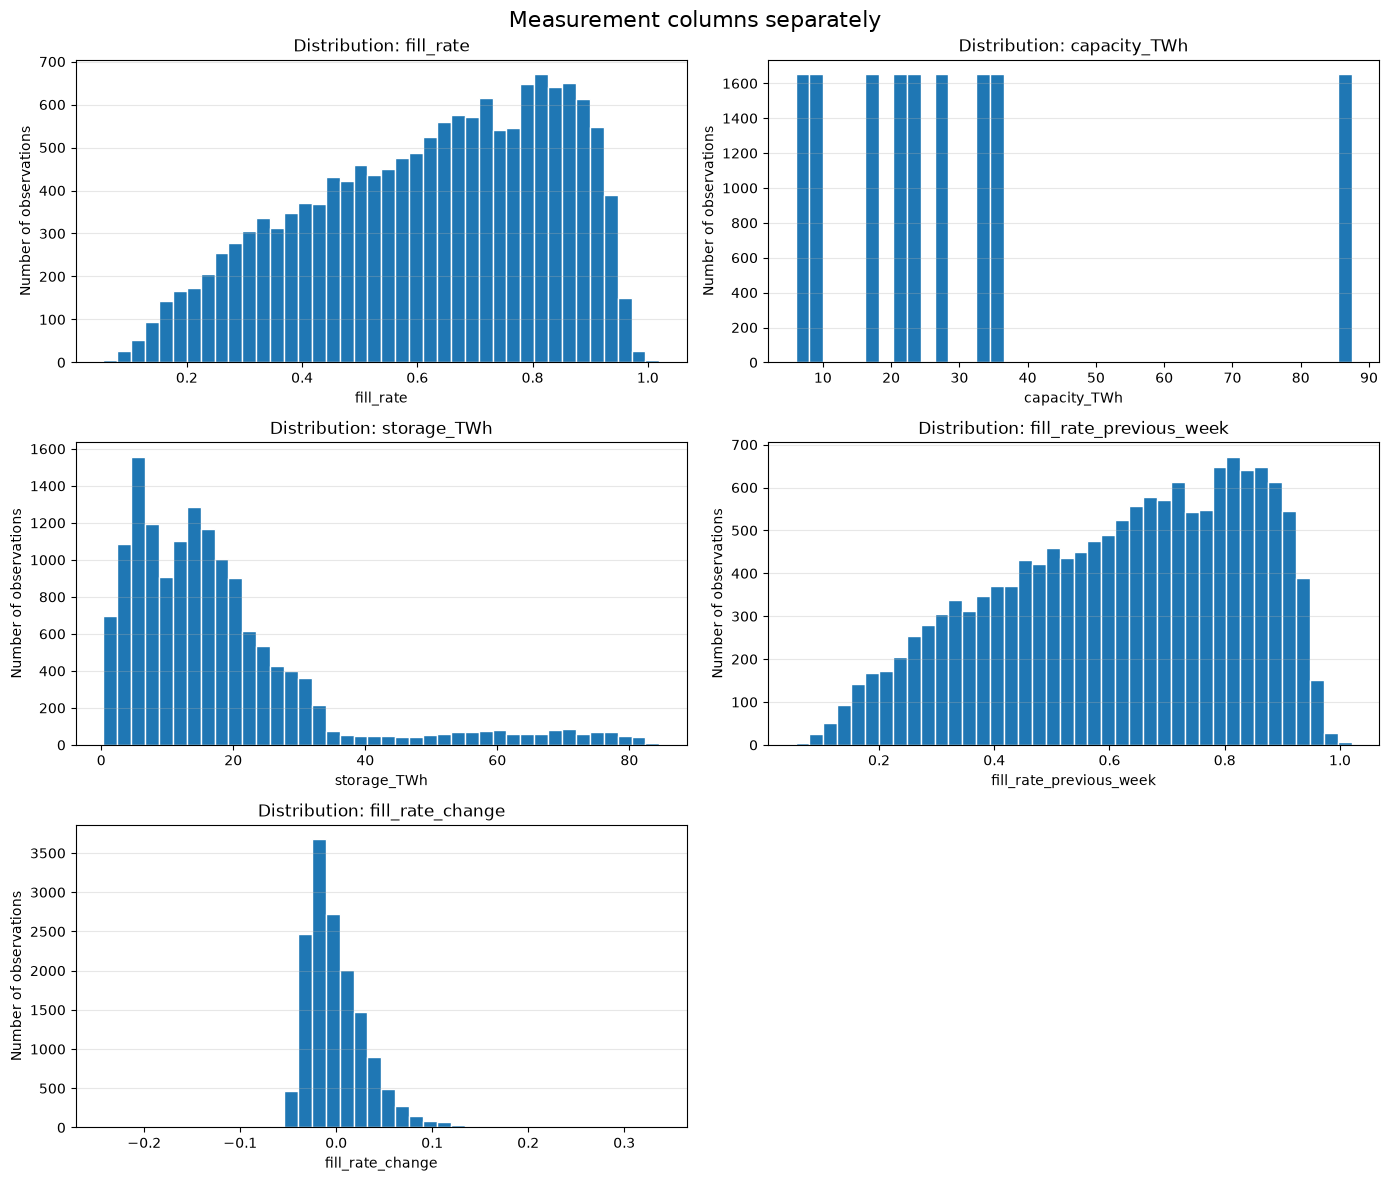

In [130]:
import matplotlib.pyplot as plt

# Plot each measurement column separately as a histogram.
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

for axis, column in zip(axes, measurement_columns):
    df[column].plot.hist(ax=axis, bins=40, edgecolor="white")
    axis.set_title(f"Distribution: {column}")
    axis.set_xlabel(column)
    axis.set_ylabel("Number of observations")
    axis.grid(axis="y", alpha=0.3)

axes[-1].set_visible(False)
fig.suptitle("Measurement columns separately", fontsize=16)
fig.tight_layout()
plt.show()


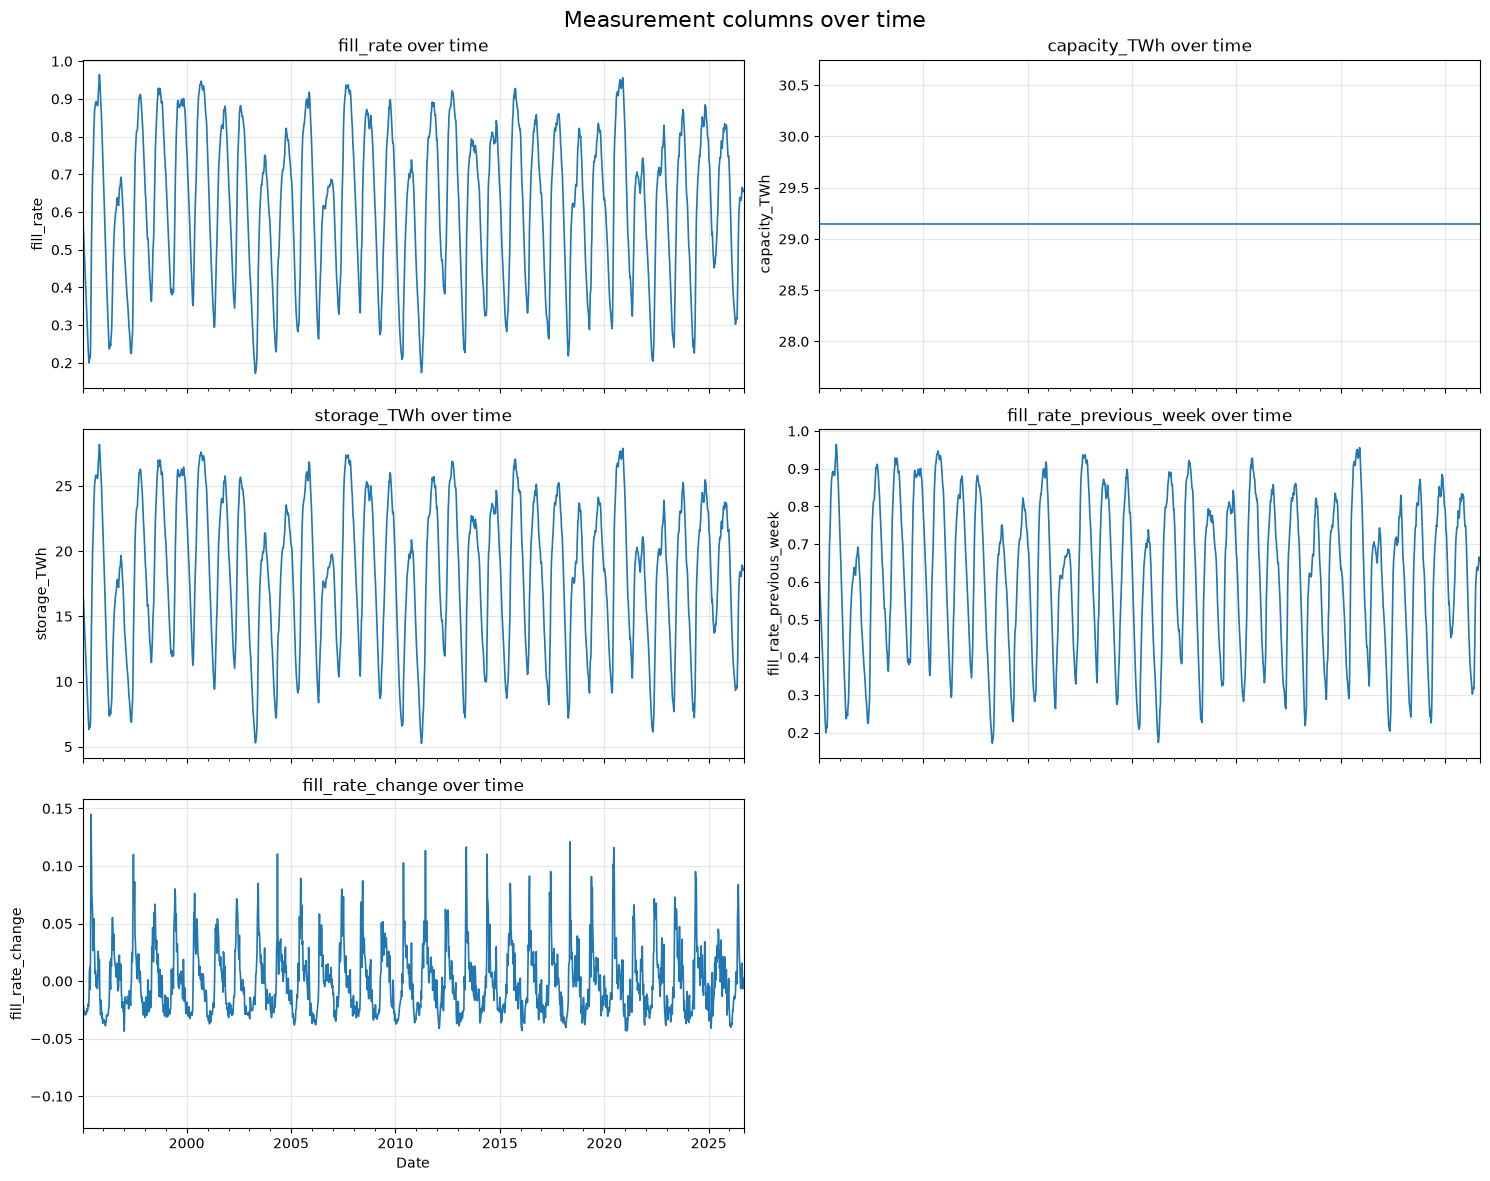

In [131]:
# Plot each measurement column separately over time.
daily_measurements = (
    df.groupby("date_Id", as_index=True)[measurement_columns]
    .mean()
    .sort_index()
)

fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
axes = axes.ravel()

for axis, column in zip(axes, measurement_columns):
    daily_measurements[column].plot(ax=axis, linewidth=1.2)
    axis.set_title(f"{column} over time")
    axis.set_ylabel(column)
    axis.grid(True, alpha=0.3)

axes[-1].set_visible(False)
axes[-2].set_xlabel("Date")
fig.suptitle("Measurement columns over time", fontsize=16)
fig.tight_layout()
plt.show()


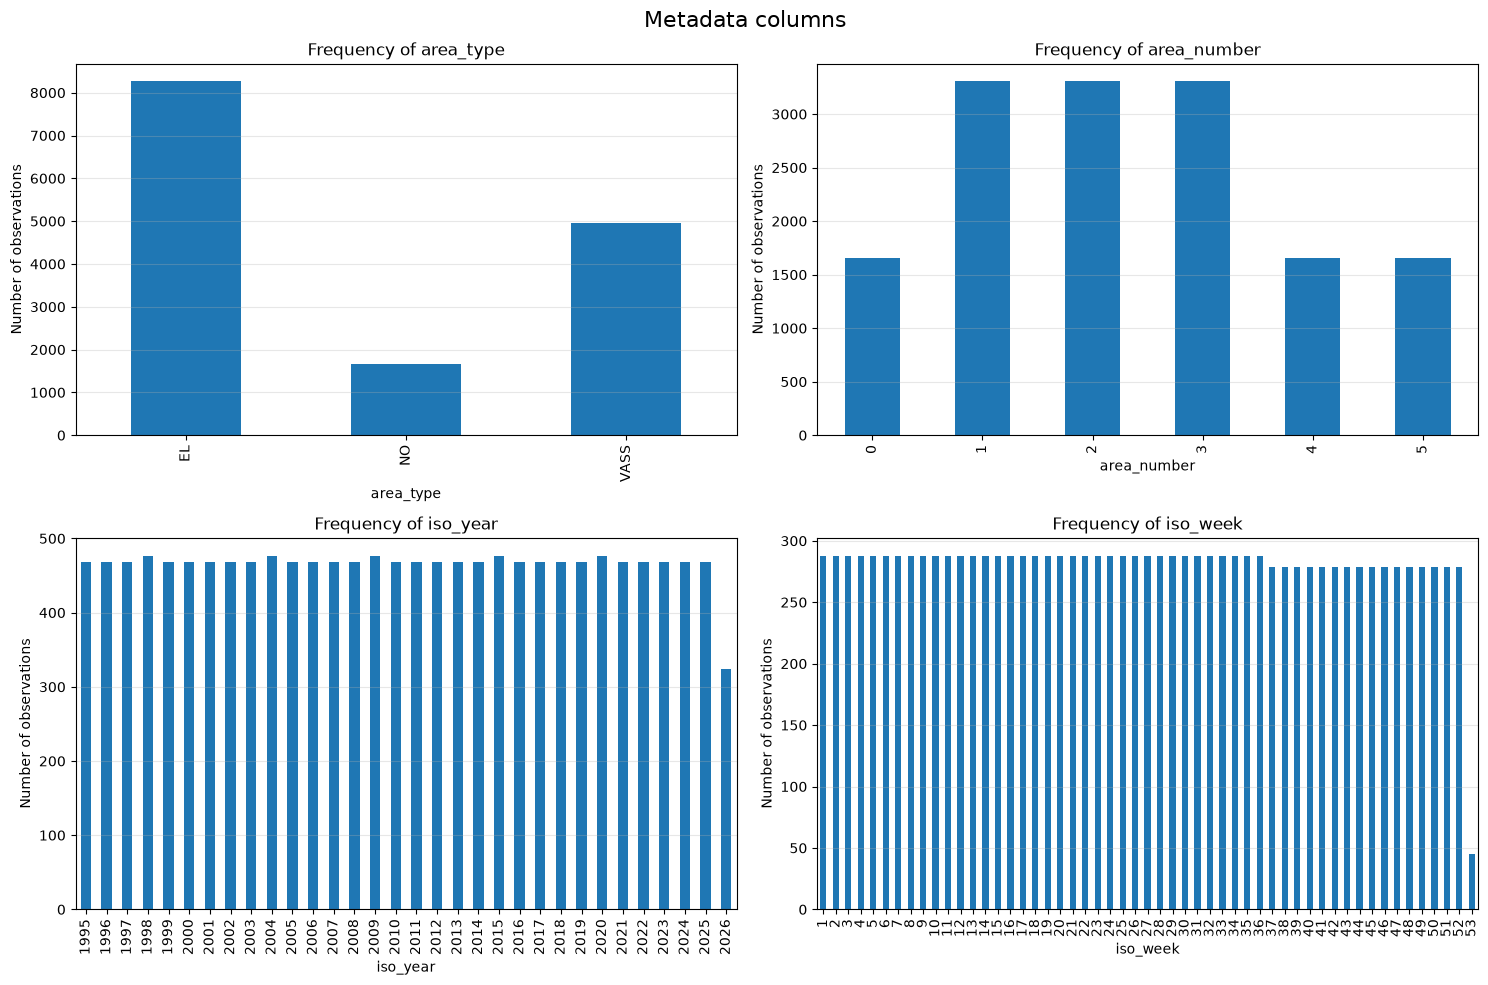

In [132]:
# Plot the remaining metadata columns using suitable frequency plots.
metadata_columns = [
    "area_type",
    "area_number",
    "iso_year",
    "iso_week"
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for axis, column in zip(axes, metadata_columns):
    df[column].value_counts().sort_index().plot.bar(ax=axis)
    axis.set_xlabel(column)

    axis.set_title(f"Frequency of {column}")
    axis.set_ylabel("Number of observations")
    axis.grid(axis="y", alpha=0.3)

fig.suptitle("Metadata columns", fontsize=16)
fig.tight_layout()
plt.show()


Rows included in the plot: 14,877


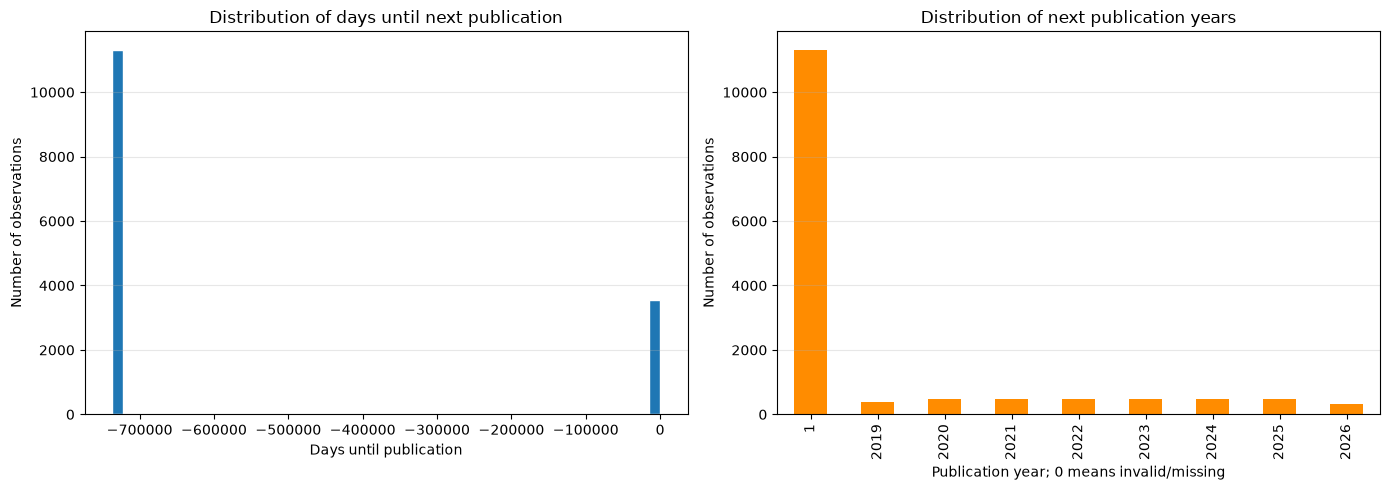

In [133]:
# Plot the time until the next publication for the full dataset.
publication_dates = pd.to_datetime(df["next_publication_date"], errors="coerce")
days_until_publication = (
    publication_dates - df["date_Id"]
).dt.days

print(f"Rows included in the plot: {len(days_until_publication):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

days_until_publication.plot.hist(bins=50, ax=axes[0], edgecolor="white")
axes[0].set_title("Distribution of days until next publication")
axes[0].set_xlabel("Days until publication")
axes[0].set_ylabel("Number of observations")
axes[0].grid(axis="y", alpha=0.3)

publication_years = publication_dates.dt.year
publication_year_counts = publication_years.value_counts(dropna=False).sort_index()
publication_year_counts.index = publication_year_counts.index.fillna(0).astype(int)
publication_year_counts.plot.bar(ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of next publication years")
axes[1].set_xlabel("Publication year; 0 means invalid/missing")
axes[1].set_ylabel("Number of observations")
axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()


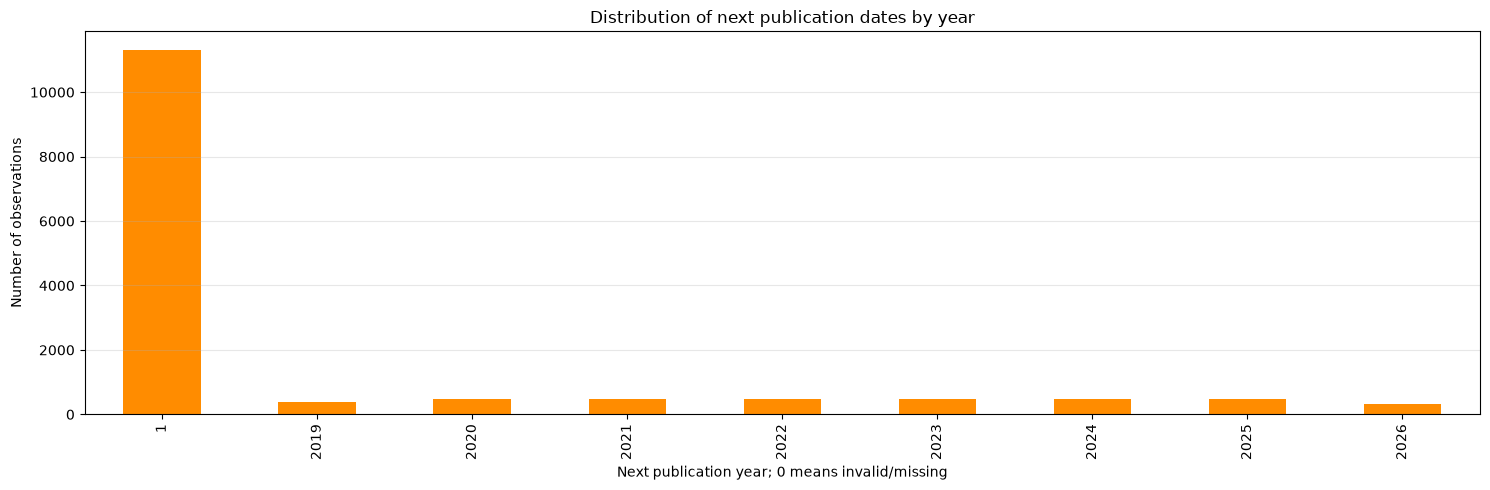

In [134]:
# Plot the distribution of every next publication date by year.
publication_dates = pd.to_datetime(df["next_publication_date"], errors="coerce")
publication_years = publication_dates.dt.year
publication_by_year = publication_years.value_counts(dropna=False).sort_index()
publication_by_year.index = publication_by_year.index.fillna(0).astype(int)

ax = publication_by_year.plot.bar(figsize=(15, 5), color="darkorange")
ax.set_title("Distribution of next publication dates by year")
ax.set_xlabel("Next publication year; 0 means invalid/missing")
ax.set_ylabel("Number of observations")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


#### There is clearly something wrong here. That there are so many dates on next publication date that is 01-01-0001 seams to me like we are missing data here.

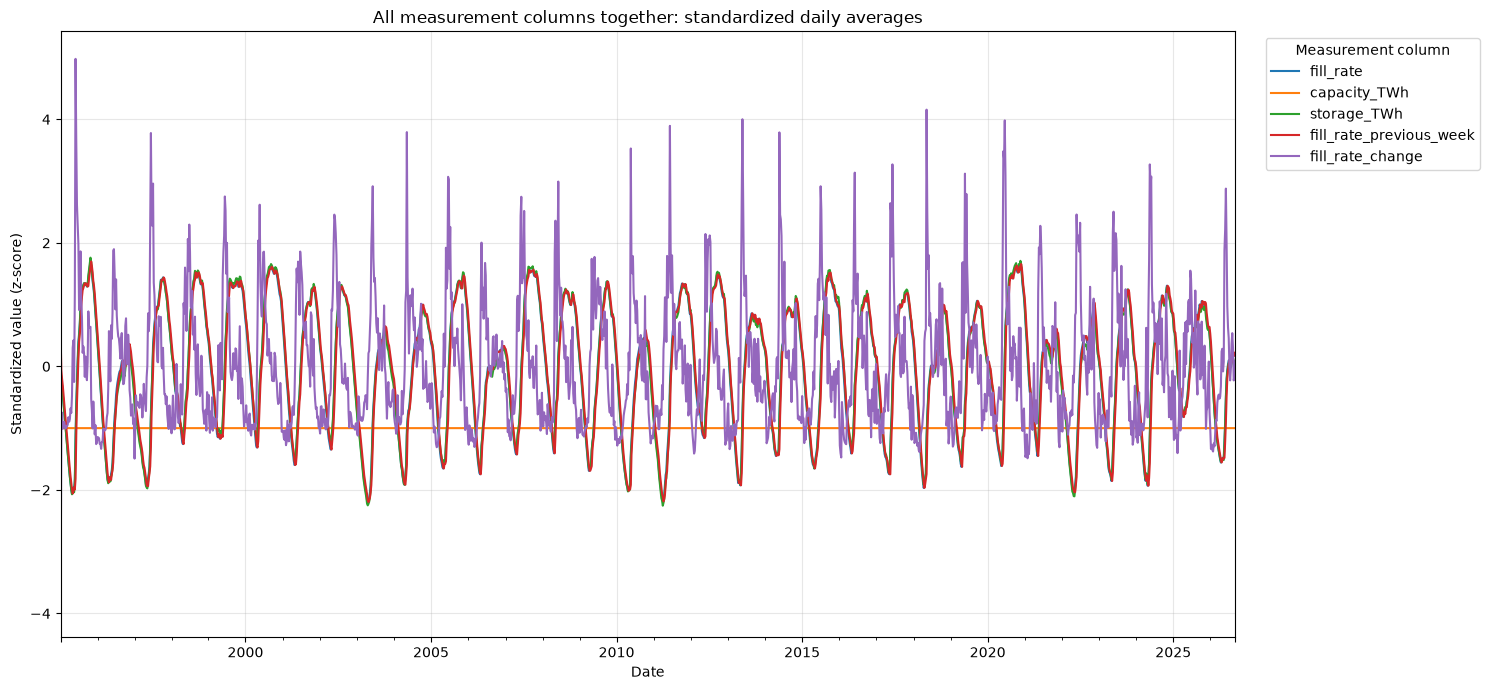

In [135]:
# Aggregate observations by date before comparing the areas.
daily_measurements = (
    df.groupby("date_Id", as_index=True)[measurement_columns]
    .mean()
    .sort_index()
)

# Standardization gives each series a mean of 0 and a standard deviation of 1.
# This makes the development comparable even though the columns use different units.
standardized_measurements = (
    daily_measurements - daily_measurements.mean()
) / daily_measurements.std()

ax = standardized_measurements.plot(figsize=(15, 7), linewidth=1.5)
ax.set_title("All measurement columns together: standardized daily averages")
ax.set_xlabel("Date")
ax.set_ylabel("Standardized value (z-score)")
ax.grid(True, alpha=0.3)
ax.legend(title="Measurement column", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
